# 读取 CSV 并提取最优指标

In [1]:
# 1. 读取两份全量训练结果 CSV，并提取最优指标
import pandas as pd

V8_CSV = "/kaggle/input/datasets/shilljinglza/model-compare/yolo_compare/v8_results.csv"
V11_CSV = "/kaggle/input/datasets/shilljinglza/model-compare/yolo_compare/v11_results.csv"

df_v8 = pd.read_csv(V8_CSV)
df_v11 = pd.read_csv(V11_CSV)
df_v8.columns = [c.strip() for c in df_v8.columns]
df_v11.columns = [c.strip() for c in df_v11.columns]

def extract_best(df, model_name, params_M):
    mAP50_col = next(c for c in df.columns if "mAP50" in c and "95" not in c)
    mAP95_col = next(c for c in df.columns if "mAP50-95" in c)
    p_col = next(c for c in df.columns if "precision" in c)
    r_col = next(c for c in df.columns if "recall" in c)
    best = df.loc[df[mAP50_col].idxmax()]
    return dict(
        model=model_name,
        mAP50=round(float(best[mAP50_col]), 4),
        mAP5095=round(float(best[mAP95_col]), 4),
        precision=round(float(best[p_col]), 4),
        recall=round(float(best[r_col]), 4),
        params_M=params_M
    )

v8b = extract_best(df_v8, "YOLOv8s", 11.2)
v11b = extract_best(df_v11, "YOLOv11s", 9.4)

results = pd.DataFrame([v8b, v11b])
print("📊 YOLOv8s vs YOLOv11s 最终性能对比（全量数据集）")
print("="*60)
print(results.to_string(index=False))
results.to_csv("/kaggle/working/final_comparison.csv", index=False)

📊 YOLOv8s vs YOLOv11s 最终性能对比（全量数据集）
   model  mAP50  mAP5095  precision  recall  params_M
 YOLOv8s 0.5338   0.4191     0.7957  0.5095      11.2
YOLOv11s 0.5472   0.4374     0.8382  0.5154       9.4


# 绘制柱状对比图

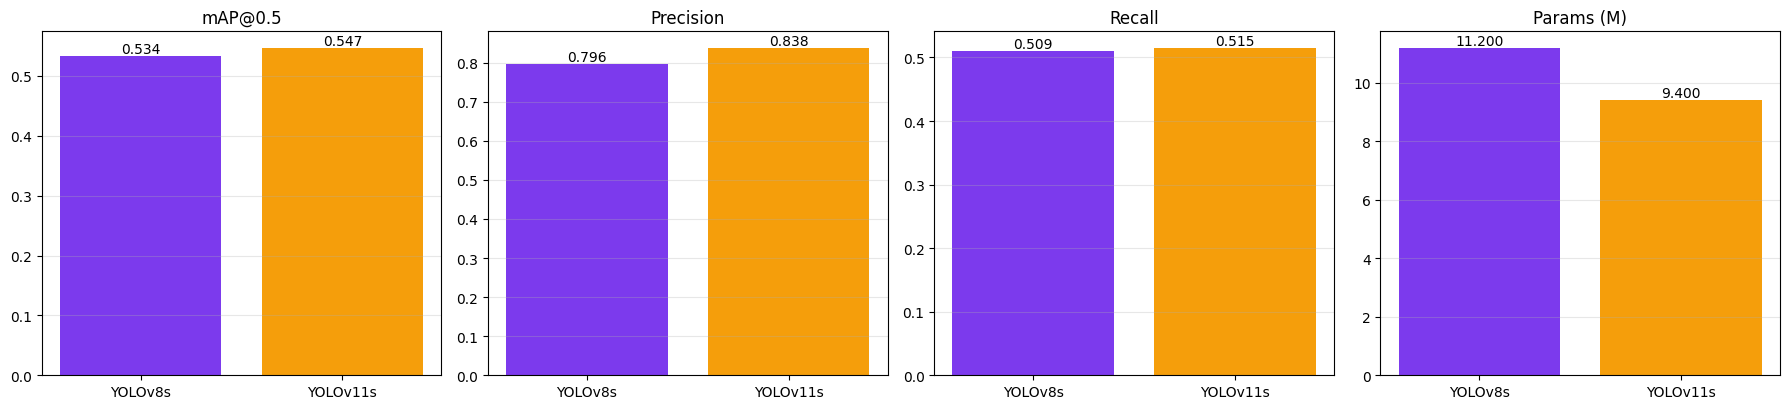

In [2]:
# 2. 柱状对比图
import matplotlib.pyplot as plt

LABELS = results["model"].tolist()
COLORS = ["#7c3aed", "#f59e0b"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
metrics = [("mAP50", "mAP@0.5"), ("precision", "Precision"),
           ("recall", "Recall"), ("params_M", "Params (M)")]

for ax, (k, t) in zip(axes, metrics):
    vals = results[k].tolist()
    bars = ax.bar(LABELS, vals, color=COLORS)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_title(t)
    ax.grid(alpha=.3, axis="y")

plt.tight_layout()
plt.savefig("/kaggle/working/compare_metrics.png", dpi=150)
plt.show()

# 绘制收敛曲线对比图

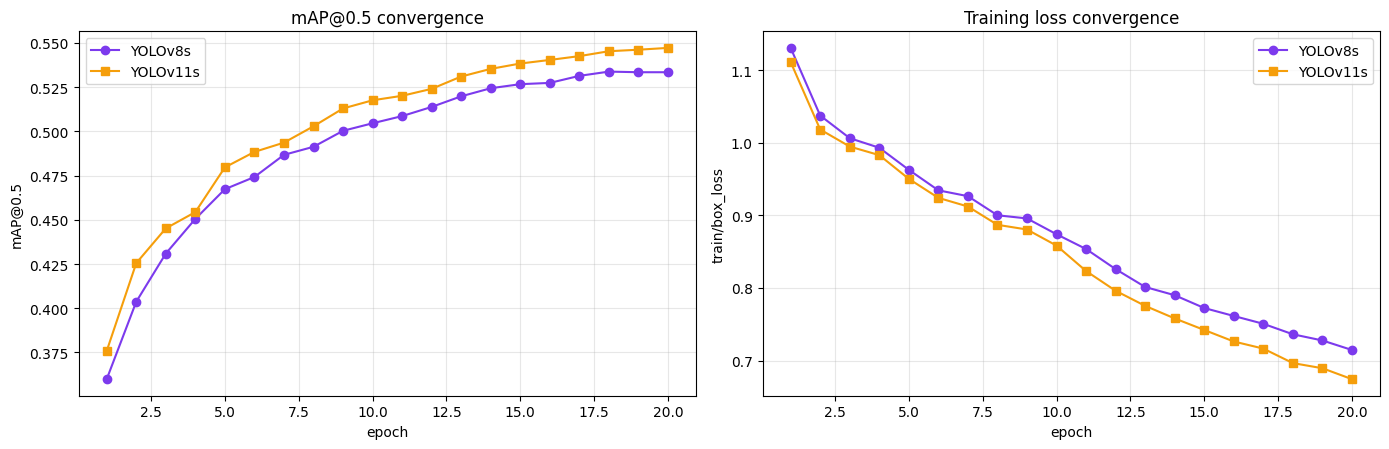

报告素材已导出: final_comparison.csv / compare_metrics.png / compare_curves.png


In [3]:
# 3. 收敛曲线对比（mAP50 与 Box Loss 随 epoch 变化）
import matplotlib.pyplot as plt

COLORS = ["#7c3aed", "#f59e0b"]
mAP_col_v8 = next(c for c in df_v8.columns if "mAP50" in c and "95" not in c)
mAP_col_v11 = next(c for c in df_v11.columns if "mAP50" in c and "95" not in c)
box_col_v8 = next(c for c in df_v8.columns if "box_loss" in c)
box_col_v11 = next(c for c in df_v11.columns if "box_loss" in c)

plt.figure(figsize=(14, 4.6))

plt.subplot(1, 2, 1)
plt.plot(df_v8["epoch"], df_v8[mAP_col_v8], marker="o", color=COLORS[0], label="YOLOv8s")
plt.plot(df_v11["epoch"], df_v11[mAP_col_v11], marker="s", color=COLORS[1], label="YOLOv11s")
plt.xlabel("epoch"); plt.ylabel("mAP@0.5")
plt.title("mAP@0.5 convergence")
plt.grid(alpha=.3); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df_v8["epoch"], df_v8[box_col_v8], marker="o", color=COLORS[0], label="YOLOv8s")
plt.plot(df_v11["epoch"], df_v11[box_col_v11], marker="s", color=COLORS[1], label="YOLOv11s")
plt.xlabel("epoch"); plt.ylabel("train/box_loss")
plt.title("Training loss convergence")
plt.grid(alpha=.3); plt.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/compare_curves.png", dpi=150)
plt.show()

print("报告素材已导出: final_comparison.csv / compare_metrics.png / compare_curves.png")